Histogram saved as disaster_events_histogram.png


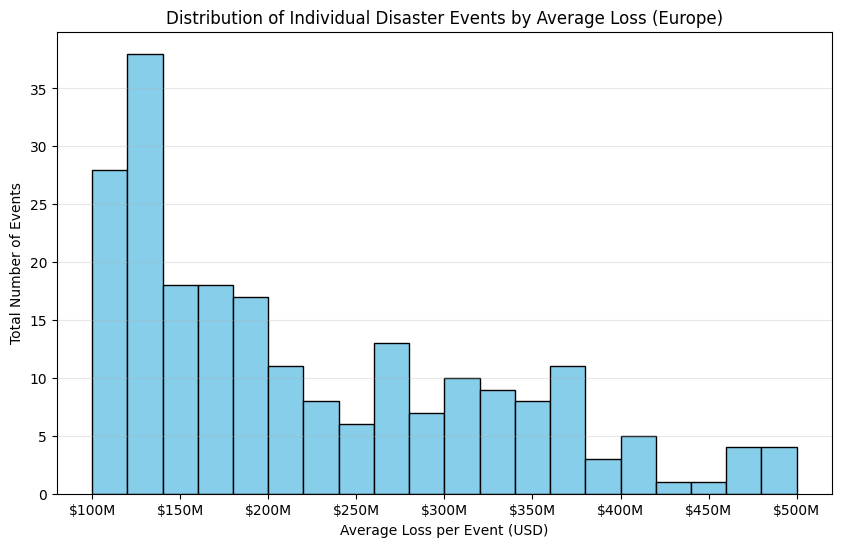

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# 1. Load and Prepare Data
file_name = '_EmergencyEventsDatabase-CountryProfiles_emdat-country-profiles_2023_04_06.csv'
df = pd.read_csv(file_name, sep=';')

# List of European countries (including historical)
europe_list = [
    'Soviet Union', 'Greece', 'Albania', 'Italy', 'Belgium', 'Romania', 'France', 'Portugal',
    'Germany Fed Rep', 'Bulgaria', 'Poland', 'Norway', 'Spain', 'Yugoslavia', 'Azores Islands',
    'Switzerland', 'Austria', 'United Kingdom of Great Britain and Northern Ireland (the)',
    'Cyprus', 'Canary Is', 'Hungary', 'Iceland', 'Czechoslovakia', 'Denmark', 'Sweden',
    'Ireland', 'Luxembourg', 'Germany Dem Rep', 'Germany', 'Finland', 'Lithuania',
    'Russian Federation (the)', 'Serbia Montenegro', 'Ukraine', 'Belarus',
    'Macedonia (the former Yugoslav Republic of)', 'Moldova (the Republic of)', 'Czech Republic (the)',
    'Croatia', 'Slovakia', 'Slovenia', 'Bosnia and Herzegovina', 'Latvia', 'Estonia',
    'Montenegro', 'Serbia', 'Isle of Man'
]

# 2. Filtering
disaster_list = ['Drought', 'Flood', 'Storm', 'Extreme temperature']
df_europe = df[
    (df['Country'].isin(europe_list)) & 
    (df['Disaster Type'].isin(disaster_list))
].copy()

# 3. Calculations
df_europe['Total Damage (USD, adjusted)'] = pd.to_numeric(df_europe['Total Damage (USD, adjusted)'], errors='coerce')
df_europe['Total Events'] = pd.to_numeric(df_europe['Total Events'], errors='coerce')

# Drop rows where we can't calculate average (0 events or no damage data)
df_europe = df_europe.dropna(subset=['Total Damage (USD, adjusted)', 'Total Events'])
df_europe = df_europe[df_europe['Total Events'] > 0]

df_europe['Average Loss per Event'] = df_europe['Total Damage (USD, adjusted)'] / df_europe['Total Events']
df_europe = df_europe[ 
    (df_europe['Average Loss per Event'] > 100_000_000) & (df_europe['Average Loss per Event'] < 500_000_000)
].copy()
# 4. Generate Weighted Histogram
plt.figure(figsize=(10, 6))

# We use the 'weights' parameter to account for 'Total Events'
# We focus on the range under 1 Billion for better visibility, or remove range to see all
plt.hist(
    df_europe['Average Loss per Event'], 
    weights=df_europe['Total Events'], 
    bins=20, 
    range=(100_000_000, 500_000_000),
    color='skyblue', 
    edgecolor='black'
)

plt.title('Distribution of Individual Disaster Events by Average Loss (Europe)')
plt.xlabel('Average Loss per Event (USD)')
plt.ylabel('Total Number of Events')
plt.grid(axis='y', alpha=0.3)

# Format x-axis for readability (Millions)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

plt.savefig('disaster_events_histogram.png')
print("Histogram saved as disaster_events_histogram.png")

In [16]:
df_europe["Year"] = pd.to_numeric(df_europe["Year"], errors='coerce')
df_europe = df_europe.dropna(subset=['Year'])
np.amin(df_europe["Year"]), np.amax(df_europe["Year"])

(np.int64(1920), np.int64(2022))

In [ ]:
# 4. Generate the Probability Density Function (PDF)
plt.figure(figsize=(10, 6))

# sns.kdeplot creates the PDF using Kernel Density Estimation
# We pass 'Total Events' as weights to expand the sample space correctly
sns.kdeplot(
    data=df_filtered, 
    x='Avg_Loss', 
    weights='Total Events', 
    fill=True, 
    color='royalblue', 
    bw_adjust=0.5 # Smoothing factor
)

# Formatting
plt.title('PDF of Disaster Event Losses in Europe (1920-2022)', fontsize=14)
plt.xlabel('Loss (Adjusted USD)', fontsize=12)
plt.ylabel('Probability Density $f(x)$', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Limit x-axis for visibility (e.g., up to 1.5 Billion USD)
plt.xlim(0, 1.5e9)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig('disaster_loss_pdf.png')
print("PDF Plot saved as disaster_loss_pdf.png")